In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Preprocessing

In [2]:
df = pd.read_csv("../data/updated_data.csv")

df["ecec_diffusion"] = df["ecec_diffusion"].fillna(df["ecec_diffusion"].median())

In [3]:
ecec_covariates = ["ecec_participation", "coverage", "public_coverage", "private_coverage", "per_capita_public_expenditure", 
                   "per_capita_user_contribution", "other_percapita_public_expenditure", "other_percapita_user_contrib",
                   "other_per_capita_expenditure", "ecec_diffusion"]
    
categorical_cols = ["prov_name", "urban_type"]

target = "fem_empl_rate"
offset = "wr_men"

In [4]:
to_drop = ecec_covariates + categorical_cols + [target] + [offset]
df_variables = df.drop(columns=to_drop)

n_obs, n_feat = df_variables.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")


Number of observations: 107, number of predictors: 37


## Correlation Based Selection

In [5]:
corr_matrix = df_variables.corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.85

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [6]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
              var1                   var2   corr
         empl_rate             inact_rate -0.989
net_migration_rate adj_net_migration_rate  0.985
         part_rate             inact_rate -0.978
         part_rate              empl_rate  0.973
      fem_edu_rate          male_edu_rate  0.952
        inact_rate               empl_gap -0.921
       unempl_rate              empl_rate -0.918
         empl_rate               empl_gap  0.917
         empl_rate             young_neet -0.900
         part_rate               empl_gap  0.892
        inact_rate             young_neet  0.882
         part_rate             young_neet -0.876
        inact_rate     net_migration_rate -0.873
    fertility_rate           ageing_index -0.873
         empl_rate     net_migration_rate  0.866
       unempl_rate             young_neet  0.858
       unempl_rate             inact_rate  0.852
   dependency_rate           ageing_index  0.852


In [7]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(empl_rate, 6)
(inact_rate, 6)
(part_rate, 4)
(young_neet, 4)
(net_migration_rate, 3)
(empl_gap, 3)
(unempl_rate, 3)
(ageing_index, 2)
(fem_edu_rate, 1)
(adj_net_migration_rate, 1)
(dependency_rate, 1)
(fertility_rate, 1)
(male_edu_rate, 1)


In [8]:
to_drop = ["empl_rate", "part_rate", "adj_net_migration_rate", "male_edu_rate", "empl_gap", "inact_rate", "ageing_index", "unempl_rate"]
df_reduced = df_variables.drop(columns=to_drop)

## Bayesian Lasso

In [9]:
selected_covariates = list(df_reduced.columns)

X = df[selected_covariates].to_numpy()
offset = df[offset].to_numpy()
y = df[target].to_numpy()

X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

y = y / 100
y_star = np.log(y / (1 - y))

offset = offset / 100
logit_offset = np.log(offset / (1 - offset))

n_obs, n_feat = X_star.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")



Number of observations: 107, number of predictors: 29


In [10]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_star)
    y_data = pm.Data("y_data", y_star)
    # offset = pm.Data("offset", logit_offset)

    lambda_sq = pm.Gamma("lambda_sq", alpha=2.0, beta=1.0) 
    lambda_ = pm.Deterministic("lambda", pm.math.sqrt(lambda_sq))

    sigma = pm.HalfNormal("sigma", sigma=1.0)

    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )

    intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)
    
    mu = pm.math.dot(X_data, beta) + intercept # + offset

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_sq, sigma, beta, alpha]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 663 seconds.


In [11]:
summary_beta_95 = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta_95.index = selected_covariates

summary_beta_95["contains_zero"] = (
    (summary_beta_95["hdi_2.5%"] <= 0) &
    (summary_beta_95["hdi_97.5%"] >= 0)
)

summary_beta_95 = summary_beta_95.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_95[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])

selected_covariates_df = summary_beta_95[~summary_beta_95["contains_zero"]].index.tolist()

                           mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate           -0.308    -0.362     -0.250          False
fertility_rate           -0.179    -0.242     -0.112          False
GDP                       0.077     0.023      0.131          False
young_neet               -0.072    -0.111     -0.033          False
graduate_mobility_rate    0.043    -0.009      0.099           True
n_members_family         -0.032    -0.069      0.005           True
fem_edu_rate             -0.026    -0.055      0.003           True
advanced_business_empl   -0.025    -0.073      0.023           True
dependency_rate           0.024    -0.007      0.059           True
internet_coverage_rate   -0.024    -0.047     -0.001          False
first_birth_maternal_age  0.022    -0.008      0.056           True
startup_ratio             0.020    -0.002      0.041           True
empl_growth               0.019    -0.000      0.037           True
green_m2_capita           0.018    -0.001      0

In [12]:
print(selected_covariates_df)

['fem_house_rate', 'fertility_rate', 'GDP', 'young_neet', 'internet_coverage_rate']


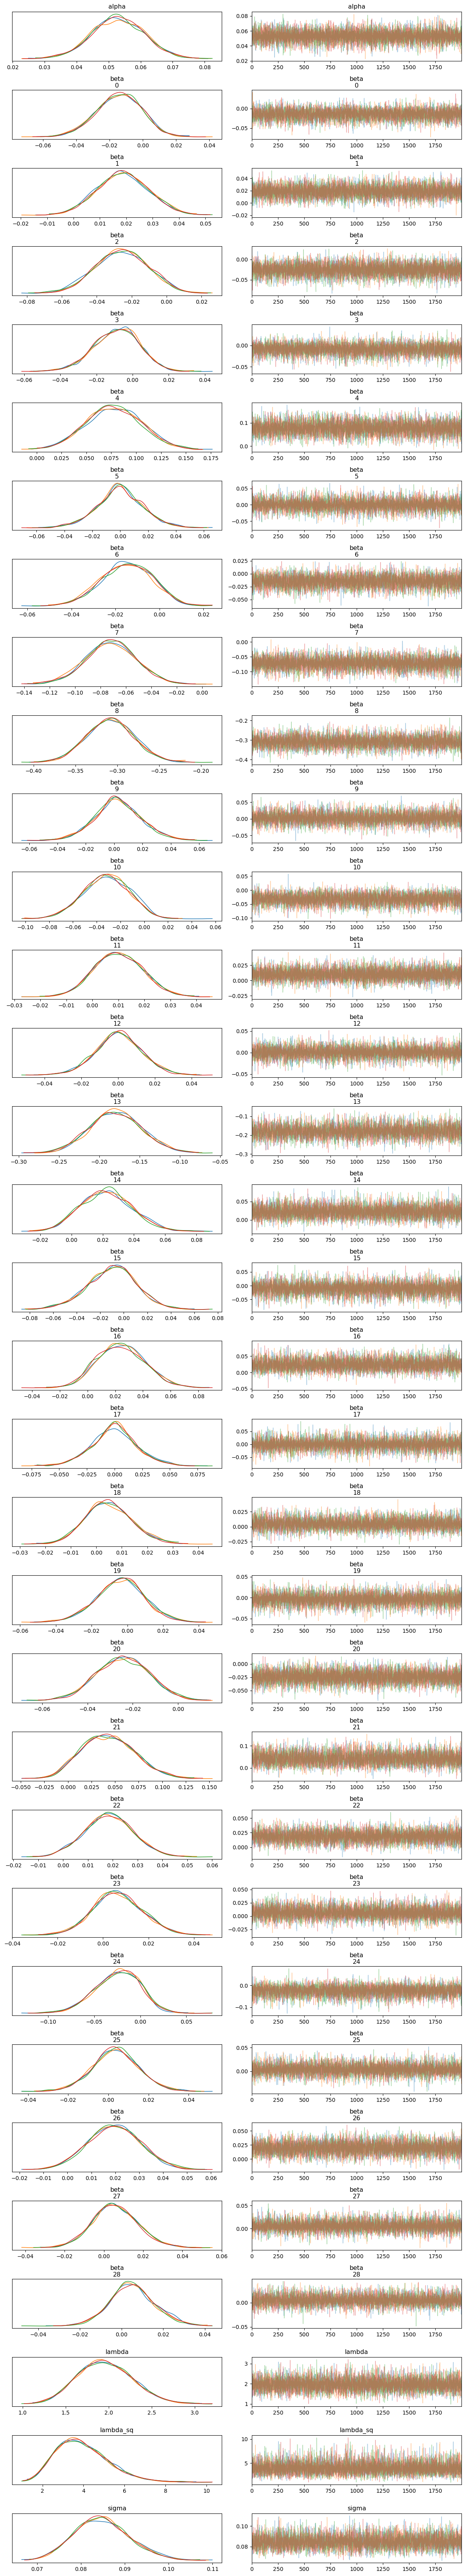

In [13]:
az.rcParams["plot.max_subplots"] = 100   
az.plot_trace(trace, compact=False)
plt.tight_layout()

# az.plot_trace(trace)
# plt.tight_layout()

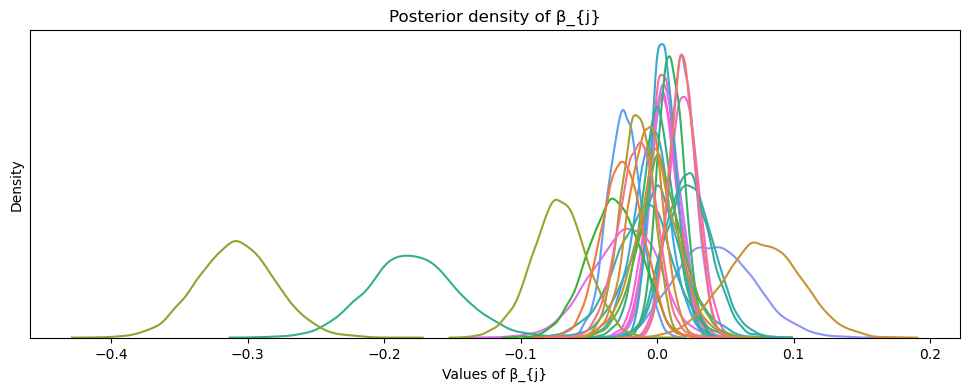

In [14]:
beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))
sns.kdeplot(beta_samples.T, legend=False)

plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()

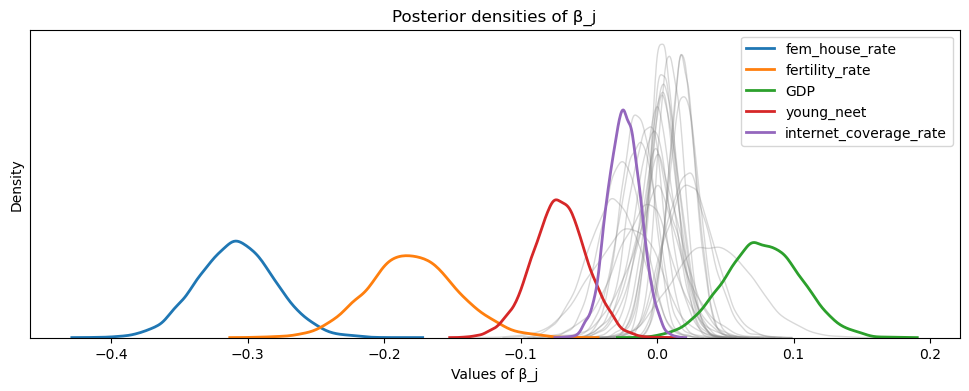

In [15]:
beta_raw = trace.posterior["beta"].stack(samples=("chain", "draw")).values  
if beta_raw.shape[0] == len(selected_covariates):
    beta_samples = beta_raw
else:
    beta_samples = beta_raw.T  

n_feat = len(selected_covariates)

plt.figure(figsize=(12, 4))

for j in range(n_feat):
    sns.kdeplot(beta_samples[j, :], color="gray", alpha=0.3, linewidth=1)

for name in summary_beta_95.index[~summary_beta_95["contains_zero"]]:
    j = selected_covariates.index(name)
    sns.kdeplot(beta_samples[j, :], linewidth=2, label=name)

plt.legend()
plt.title("Posterior densities of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()

## ECEC Covariates Correlation

In [16]:
df_ecec = df[ecec_covariates]
df_ecec = df_ecec.drop(columns=["private_coverage"])

In [17]:
len(ecec_covariates)

10

In [18]:
corr_matrix = df[df_ecec.columns].corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.75

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [19]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
                              var1                          var2   corr
other_percapita_public_expenditure  other_per_capita_expenditure  0.995
                ecec_participation per_capita_public_expenditure  0.825
     per_capita_public_expenditure  per_capita_user_contribution  0.790
                ecec_participation  per_capita_user_contribution  0.788


In [20]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(ecec_participation, 2)
(per_capita_user_contribution, 2)
(per_capita_public_expenditure, 2)
(other_percapita_public_expenditure, 1)
(other_per_capita_expenditure, 1)


In [21]:
ecec_to_drop = ["other_per_capita_expenditure", "per_capita_user_contribution", "ecec_participation"]

df_ecec = df_ecec.drop(columns=ecec_to_drop)

ecec_selected = list(df_ecec.columns)

## Results

In [22]:
final_covariates = selected_covariates_df + ecec_selected
print(f"{len(final_covariates)} selected covariates:")
print(final_covariates)

11 selected covariates:
['fem_house_rate', 'fertility_rate', 'GDP', 'young_neet', 'internet_coverage_rate', 'coverage', 'public_coverage', 'per_capita_public_expenditure', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'ecec_diffusion']


In [23]:
freq_lasso_selection = ["coverage", "ecec_diffusion", "per_capita_public_expenditure", "ecec_participation", "per_capita_user_contribution", "ageing_index", "service_empl_rate", "n_members_family", "avg_children_per_woman", "fem_house_rate"]

In [24]:
all_covariates = (set(final_covariates) | set(freq_lasso_selection))

# Build and print the table
print(f"{'covariate':40s} | {'in_final_covariates':20s} | {'in_freq_lasso':15s}")
print("-" * 85)

for cov in all_covariates:
    in_final = cov in final_covariates
    in_freq  = cov in freq_lasso_selection
    print(f"{cov:40s} | {str(in_final):20s} | {str(in_freq):15s}")

covariate                                | in_final_covariates  | in_freq_lasso  
-------------------------------------------------------------------------------------
coverage                                 | True                 | True           
internet_coverage_rate                   | True                 | False          
ecec_diffusion                           | True                 | True           
public_coverage                          | True                 | False          
fertility_rate                           | True                 | False          
per_capita_user_contribution             | False                | True           
per_capita_public_expenditure            | True                 | True           
GDP                                      | True                 | False          
other_percapita_public_expenditure       | True                 | False          
fem_house_rate                           | True                 | True           
avg_children